Mūsų testavimas (kartojimas)

In [120]:
import seaborn as sns

In [121]:
# load dataset titanic
df = sns.load_dataset('titanic')

In [122]:
import pandas as pd

# df_2 = pd.read_csv("Kelias/failas.csv")

In [123]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [124]:
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
columns_to_drop = ['deck', 'embark_town', 'alive', 'who','class']

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [127]:
df.nunique() # duoda kiekvienos klasės unikalių reikšmių kieki

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [128]:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].value_counts())

Column: survived
survived
0    549
1    342
Name: count, dtype: int64
Column: pclass
pclass
3    491
1    216
2    184
Name: count, dtype: int64
Column: sex
sex
male      577
female    314
Name: count, dtype: int64
Column: age
age
24.00    30
22.00    27
18.00    26
28.00    25
30.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
Column: sibsp
sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64
Column: parch
parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64
Column: fare
fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
           ..
13.8583     1
50.4958     1
5.0000      1
9.8458      1
10.5167     1
Name: count, Length: 248, dtype: int64
Column: embarked
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Column: class
class
Third     491
First     216
Second    184
Name: count, dtype: int64
Col

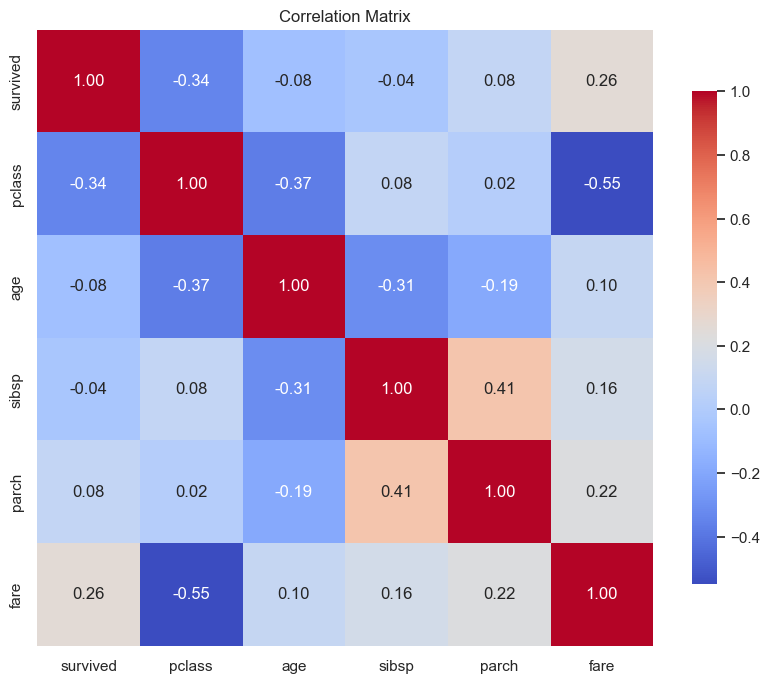

In [129]:
# let's draw some graphs to understand data better
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid")
sns.set_palette("pastel")
sns.set_context("notebook")

# correlation matrix
corr = df.select_dtypes(['number']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix")
plt.show()

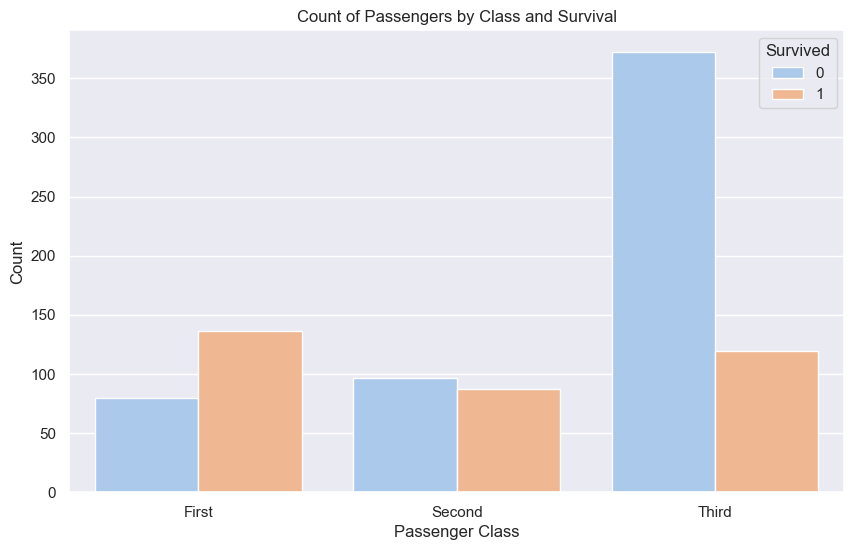

In [130]:
# draw more graphs to understand data better
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class', hue='survived')
plt.title("Count of Passengers by Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.legend(title='Survived', loc='upper right')
plt.show()

In [131]:
df.drop(columns=columns_to_drop, inplace=True)

In [132]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,True,True
887,1,1,female,19.0,0,0,30.0000,S,False,True
888,0,3,female,NaN,1,2,23.4500,S,False,False
889,1,1,male,26.0,0,0,30.0000,C,True,True


In [133]:
# # remove outliers
# # remove outliers from age column
# # columns to remove outliers
# columns_to_remove_outliers = ['age', 'fare', 'sibsp', 'parch']
# for col in columns_to_remove_outliers:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 5 * IQR
#     upper_bound = Q3 + 5 * IQR
#     df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


In [134]:
# another outlier removal method
# remove outliers from age column
# columns to remove outliers
columns_to_remove_outliers = ['age', 'fare', 'sibsp', 'parch']
# without inter quartile range
for col in columns_to_remove_outliers:
    mean = df[col].mean()
    std = df[col].std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [136]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df.drop('survived', axis=1), df['survived'], test_size=0.2, random_state=42)

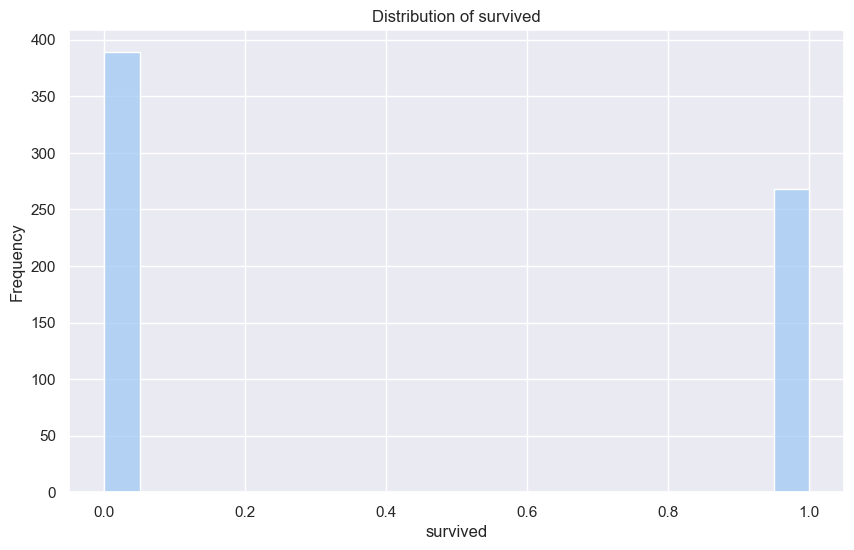

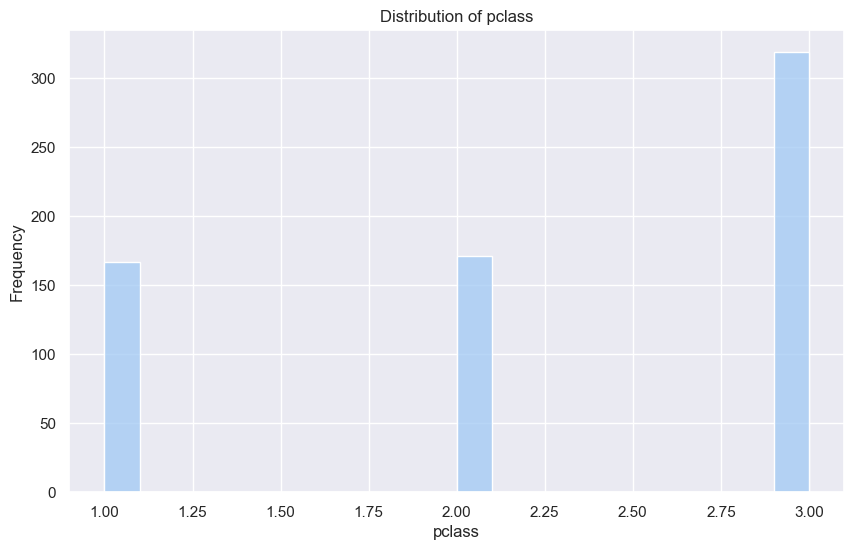

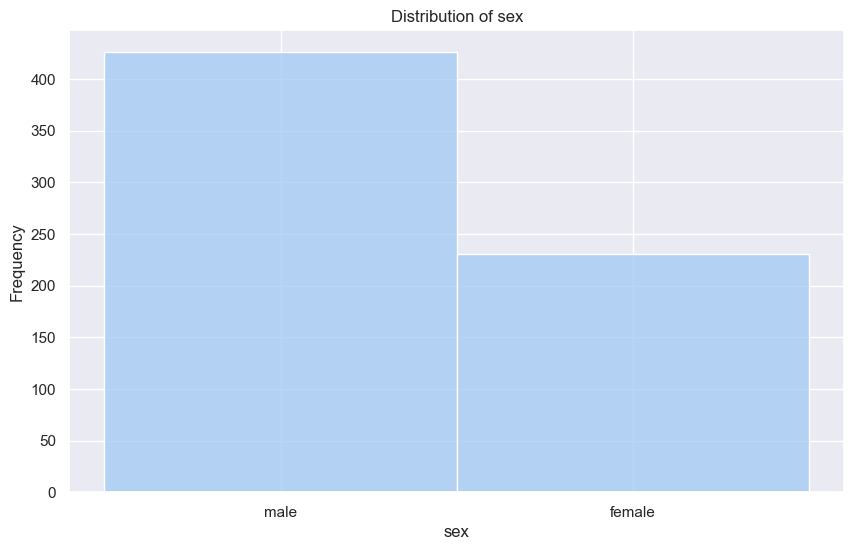

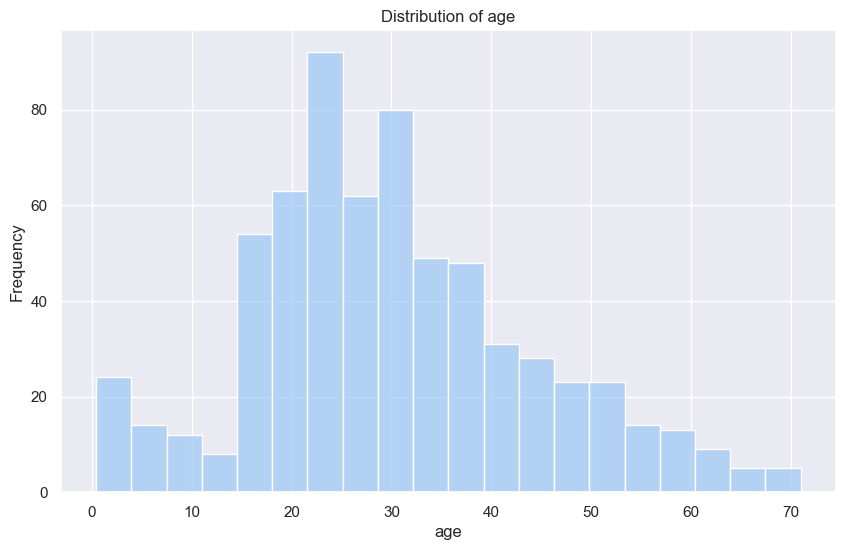

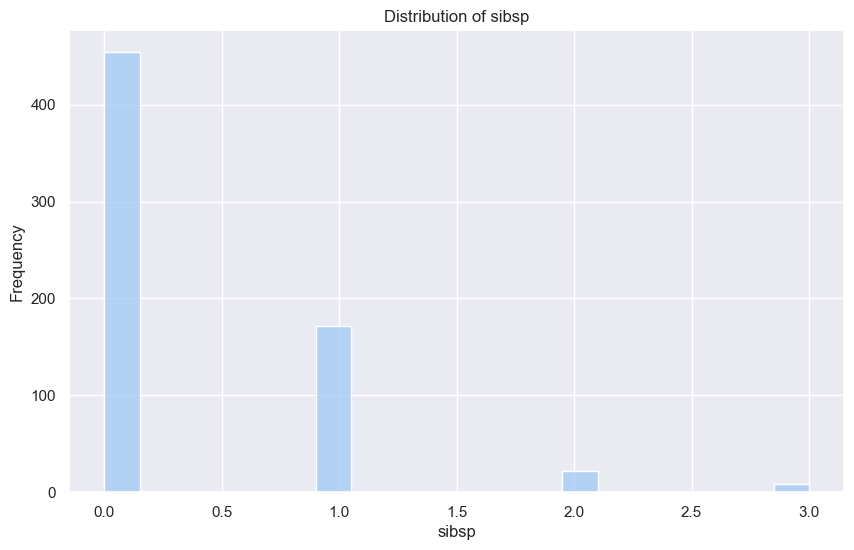

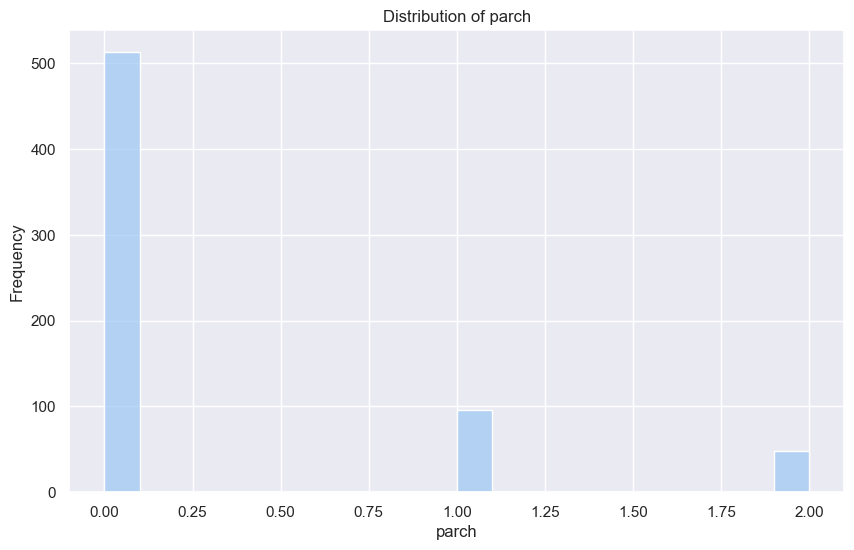

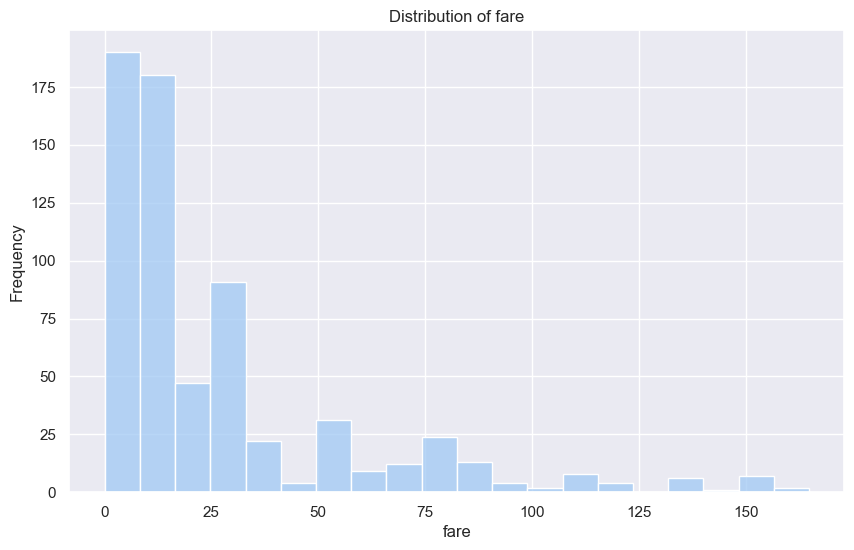

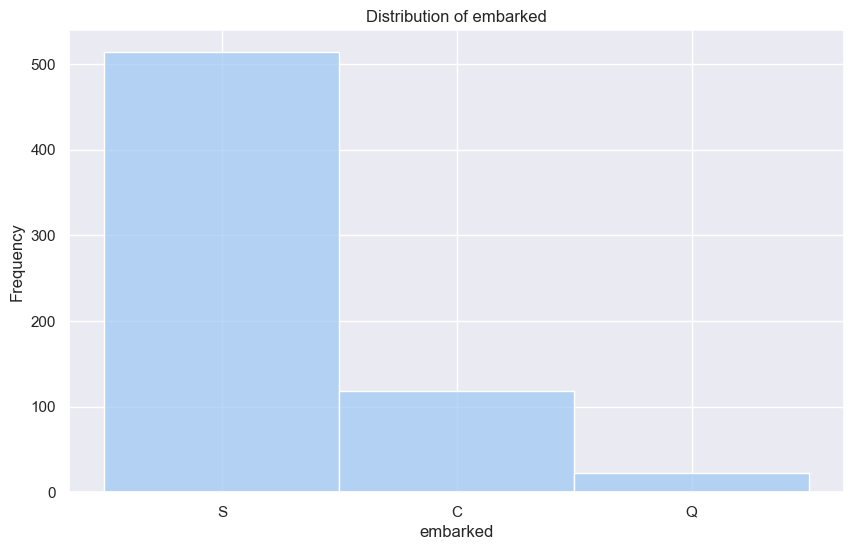

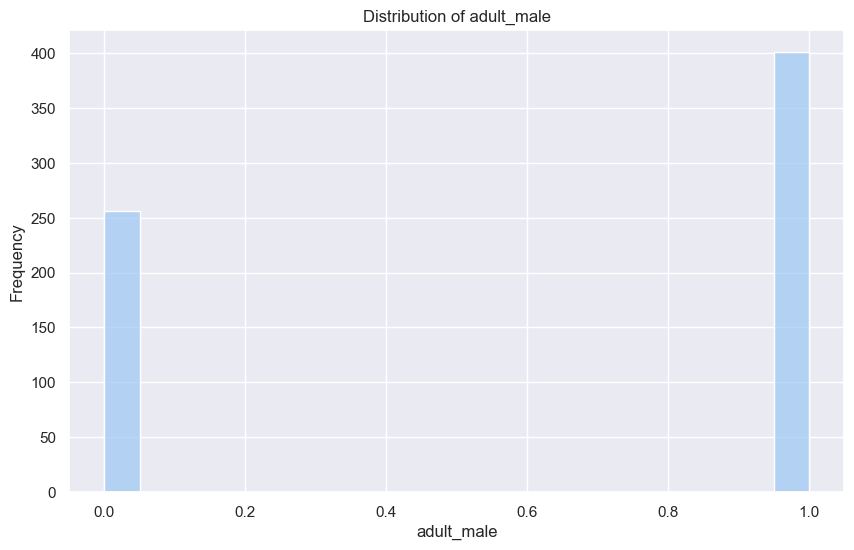

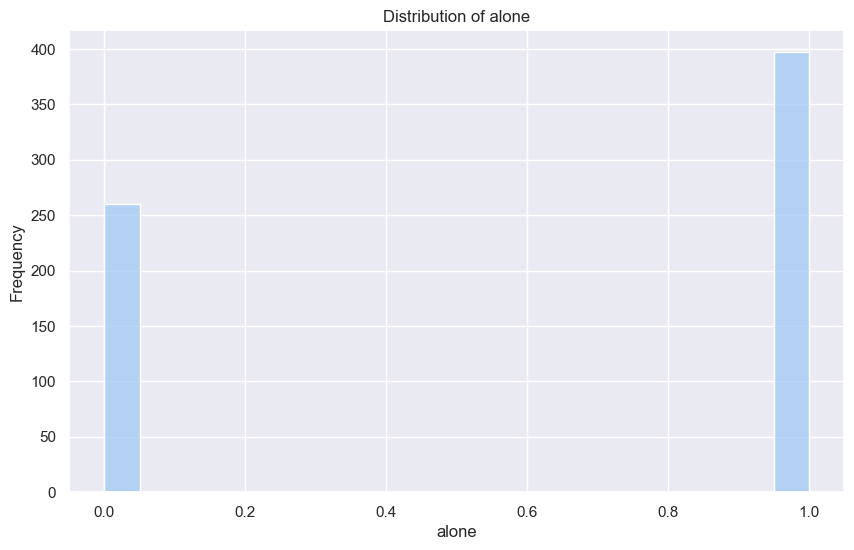

In [142]:
# show column distributions
for col in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[col], bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [144]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,True,False
1,1,1,female,38.0,1,0,71.2833,C,False,False
2,1,3,female,26.0,0,0,7.9250,S,False,True
3,1,1,female,35.0,1,0,53.1000,S,False,False
4,0,3,male,35.0,0,0,8.0500,S,True,True
...,...,...,...,...,...,...,...,...,...,...
884,0,3,male,25.0,0,0,7.0500,S,True,True
886,0,2,male,27.0,0,0,13.0000,S,True,True
887,1,1,female,19.0,0,0,30.0000,S,False,True
889,1,1,male,26.0,0,0,30.0000,C,True,True


In [145]:
from sklearn.preprocessing import StandardScaler
# standartize only numerical columns
numerical_cols = ['age', 'fare', 'sibsp', 'parch']
# Scale the features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [146]:
X_train

,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
313,3,male,-0.169007,-0.603065,-0.475823,-0.655584,S,True,True
761,3,male,0.765230,-0.603065,-0.475823,-0.679953,S,True,True
494,3,male,-0.672058,-0.603065,-0.475823,-0.650709,S,True,True
92,1,male,1.124552,0.995970,-0.475823,1.028837,S,True,False
789,1,male,1.124552,-0.603065,-0.475823,1.598698,C,True,True
...,...,...,...,...,...,...,...,...,...
104,3,male,0.477772,2.595005,-0.475823,-0.654661,S,True,False
147,3,female,-1.534431,2.595005,2.899947,0.181555,S,False,False
370,1,male,-0.384600,0.995970,-0.475823,0.847579,C,True,False
592,3,male,1.196416,-0.603065,-0.475823,-0.676001,S,True,True


In [147]:
# one hot encoding for categorical columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


In [152]:
X_test.describe(include='all')

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S
count,132.000000,132.000000,132.000000,132.000000,132.000000,132,132,132,132,132
unique,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,True,True,True,False,True
freq,NaN,NaN,NaN,NaN,NaN,85,79,91,128,110
mean,2.333333,-0.080538,-0.057939,0.086806,-0.104991,NaN,NaN,NaN,NaN,NaN
std,0.816497,1.038467,0.944030,1.014590,0.929523,NaN,NaN,NaN,NaN,NaN
min,1.000000,-2.127312,-0.603065,-0.475823,-0.905210,NaN,NaN,NaN,NaN,NaN
25%,2.000000,-0.743922,-0.603065,-0.475823,-0.654661,NaN,NaN,NaN,NaN,NaN
50%,3.000000,-0.169007,-0.603065,-0.475823,-0.494215,NaN,NaN,NaN,NaN,NaN
75%,3.000000,0.405908,0.995970,1.212062,-0.065832,NaN,NaN,NaN,NaN,NaN


In [150]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV

# Create a KNN classifier
knn = KNeighborsClassifier(5)
# Fit the classifier to the training data
knn.fit(X_train, y_train)
# Make predictions on the test data
y_pred = knn.predict(X_test)
# Evaluate the classifier
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[67 16]
 [13 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82        83
           1       0.69      0.73      0.71        49

    accuracy                           0.78       132
   macro avg       0.76      0.77      0.77       132
weighted avg       0.78      0.78      0.78       132

